# Qualifying: เวลาซ้อมอย่างเดียว เทียบกับเวลาซ้อมและยาง
อ่านจากบนลงล่างแล้ว Run All ได้ โค้ดหลักอยู่ในเล่มนี้ ไม่ต้องเปิดไฟล์ Python อื่นเพื่อเข้าใจขั้นตอน

## 1. กำหนดโจทย์
เราจะทำนาย **เวลาต่ำสุดที่ใช้ได้จาก Q1/Q2/Q3** หน่วยวินาที ไม่ใช่อันดับ Qualifying และไม่ใช่ผลการแข่งขัน
หนึ่งแถวหมายถึงนักขับหนึ่งคนในหนึ่งรายการแข่ง

- ชุดเวลา: FP1_Time, FP2_Time, FP3_Time รวม 3 features
- ชุดเวลา+ยาง: Time, Compound, TyreLife ของ FP1–FP3 รวม 9 features ก่อน encoding
- นักขับ ทีม สนาม และปี มีไว้เชื่อมตาราง/แบ่งชุด/รายงานผล ไม่เข้า X; weather ไม่เข้า X
- ข้อมูลยางต้องมาจาก lap เดียวกับเวลาที่เลือก

คำถามของการทดลองคือ “การเพิ่มข้อมูลยางช่วยลดความผิดพลาดในการทำนายหรือไม่” ไม่ใช่พิสูจน์ว่ายางเป็นสาเหตุที่ทำให้ Qualifying เร็วขึ้น

### เตรียมสำหรับ Colab (ข้ามได้เมื่อใช้ Docker)
ถ้าเปิดเฉพาะไฟล์ ipynb บน Colab ให้รัน cell นี้ก่อน โดยเปลี่ยน `SETUP_COLAB=True`
ระบบจะ clone branch docker เพื่อเอา snapshot และ dependencies มาด้วย ไม่ต้อง upload cache
หากแก้ Notebook ใน Colab ให้ดาวน์โหลด ipynb กลับมาเอง การแก้ใน Colab ไม่ได้แก้ Git อัตโนมัติ

In [1]:
SETUP_COLAB = False
if SETUP_COLAB:
    import subprocess, sys
    from pathlib import Path
    checkout = Path("/content/f1-project")
    if not checkout.exists():
        subprocess.run(["git", "clone", "--branch", "docker",
                        "https://github.com/bigtalay/mini-project-ML-f1-qualify-time-prediction-.git",
                        str(checkout)], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-r",
                    str(checkout / "requirements.lock")], check=True)
    import os
    os.chdir(checkout / "f1_project")

## 2. รวบรวมและสำรวจข้อมูล
### 2.1 ตั้งค่าโฟลเดอร์
raw เดิมจะอ่านอย่างเดียว ตัวอย่างที่ดึงใหม่จะอยู่ใน `data/downloads`; CSV ที่ clean แล้วและ features อยู่ใน `artifacts/practice-tyres-notebook` เพื่อไม่ปนกับ raw หรือ artifact ของเว็บ

In [2]:
from pathlib import Path
import os, json, hashlib
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "data/raw").exists():
    ROOT = ROOT / "f1_project"
assert (ROOT / "data/raw/practice_laps.csv").exists(), "เปิด notebook จากโฟลเดอร์ project"
RAW = ROOT / "data/raw"
REFERENCE = ROOT / "data/reference"
CACHE = ROOT / "f1_cache"
DOWNLOADS = ROOT / "data/downloads"
PROCESSED = ROOT / "artifacts/practice-tyres-notebook"
for path in [CACHE, DOWNLOADS, PROCESSED]:
    path.mkdir(parents=True, exist_ok=True)
display(pd.DataFrame({"folder": ["raw (read only)", "cache", "download", "processed / model"],
                      "absolute_path": [str(p.resolve()) for p in [RAW, CACHE, DOWNLOADS, PROCESSED]]}))

def checksums(folder):
    return {p.name: hashlib.sha256(p.read_bytes().replace(b"\r\n", b"\n")).hexdigest()
            for p in sorted(folder.glob("*.csv"))}

raw_before = checksums(RAW)
manifest = json.loads((REFERENCE / "manifest.json").read_text())
assert raw_before == manifest["sha256"]

,folder,absolute_path
0,raw (read only),/workspace/f1_project/data/raw
1,cache,/workspace/f1_project/f1_cache
2,download,/workspace/f1_project/data/downloads
3,processed / model,/workspace/f1_project/artifacts/practice-tyres...


### 2.2 ดึง Bahrain 2023 ให้เห็นจริง
FastF1 ไม่ใช่ไฟล์ dataset สำเร็จรูป แต่เป็น Python library สำหรับอ่าน timing data เราจะโหลด Practice และผล Qualifying แล้วเลือกคอลัมน์ก่อน export โดยยังไม่ตัด lap

`f1_cache` เป็นข้อมูลที่ FastF1 เก็บเพื่อลดการดาวน์โหลดซ้ำ การโหลดครั้งนี้อาจอ่าน cache ไม่ได้หมายความว่าต้องดาวน์โหลดใหม่ทั้งหมด
ตั้ง `F1_OFFLINE=1` ใน environment เพื่อข้ามตัวอย่างเครือข่ายและฝึกด้วย snapshot ได้

In [3]:
import fastf1
from fastf1 import _api

fastf1.Cache.enable_cache(str(CACHE))
DOWNLOAD_SAMPLE = os.environ.get("F1_OFFLINE", "0") != "1"
DOWNLOAD_ALL = False
lap_columns = ["Time", "Driver", "DriverNumber", "LapTime", "LapNumber", "Stint",
               "Sector1Time", "Sector2Time", "Sector3Time", "SpeedI1", "SpeedI2",
               "SpeedFL", "SpeedST", "Compound", "TyreLife", "FreshTyre", "Team",
               "TrackStatus", "Deleted", "DeletedReason", "FastF1Generated", "IsAccurate"]
aliases = {"Practice 1": "FP1", "Practice 2": "FP2", "Practice 3": "FP3", "Qualifying": "Q"}

def download_event(year, round_number):
    event = fastf1.get_event(year, round_number)
    laps, timing = [], []
    results = None
    for slot in range(1, 6):
        session_code = aliases.get(event[f"Session{slot}"])
        if session_code is None:
            continue
        session = fastf1.get_session(year, round_number, session_code)
        session.load(telemetry=False, weather=False, laps=session_code != "Q", messages=False)
        info = _api.session_info(session.api_path)
        timing.append({"event_id": f"{year}-{round_number:02d}", "session": session_code,
                       "start_utc": (pd.Timestamp(info["StartDate"]) - info["GmtOffset"]).tz_localize("UTC"),
                       "end_utc": (pd.Timestamp(info["EndDate"]) - info["GmtOffset"]).tz_localize("UTC")})
        if session_code == "Q":
            results = pd.DataFrame(session.results)[["Abbreviation", "Q1", "Q2", "Q3"]].rename(columns={"Abbreviation": "Driver"})
            for c in ["Q1", "Q2", "Q3"]:
                results[c] = results[c].dt.total_seconds()
            results.insert(0, "Circuit", event.EventName)
            results.insert(0, "Year", year)
        else:
            part = pd.DataFrame(session.laps).reindex(columns=lap_columns).copy()
            for c in ["Time", "LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]:
                part[c] = pd.to_timedelta(part[c]).dt.total_seconds()
            part.insert(0, "Session", session_code)
            part.insert(0, "Circuit", event.EventName)
            part.insert(0, "Year", year)
            laps.append(part)
    if not laps or results is None:
        raise ValueError("ข้อมูล event ไม่ครบ จึงไม่บันทึกว่าเสร็จ")
    return pd.concat(laps, ignore_index=True), results, pd.DataFrame(timing)

In [4]:
sample = None
if DOWNLOAD_SAMPLE:
    try:
        sample, sample_results, sample_sessions = download_event(2023, 1)
        print("FastF1 load สำเร็จ (อาจใช้ cache): Bahrain 2023")
        display(sample.head(10))
        display(sample[["LapTime", "Compound", "TyreLife"]].isna().sum().to_frame("missing ก่อน clean"))
    except Exception as error:
        print(f"ตัวอย่างดึงข้อมูลไม่สำเร็จ: {type(error).__name__}: {error}")
        print("การฝึกจาก snapshot ยังทำต่อได้ ไม่ได้แทนผลดึงสดด้วยข้อมูลสมมุติ")
else:
    print("OFFLINE: ข้าม FastF1 load ใช้ snapshot สำหรับการฝึก")

core           INFO 	Loading data for Bahrain Grand Prix - Practice 1 [v3.8.3]


req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data


req            INFO 	Using cached data for track_status_data


...

core           INFO 	Finished loading data for 20 drivers: ['1', '11', '16', '55', '14', '63', '44', '18', '31', '27', '4', '77', '24', '22', '23', '2', '20', '81', '21', '10']


req            INFO 	Using cached data for session_info


FastF1 load สำเร็จ (อาจใช้ cache): Bahrain 2023


,Year,Circuit,Session,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,Sector1Time,...,SpeedST,Compound,TyreLife,FreshTyre,Team,TrackStatus,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,2023,Bahrain Grand Prix,FP1,1274.563,VER,1,NaN,1.0,1.0,NaN,...,187.0,MEDIUM,1.0,True,Red Bull Racing,1,None,,False,False
1,2023,Bahrain Grand Prix,FP1,1369.992,VER,1,95.429,2.0,1.0,30.535,...,314.0,MEDIUM,2.0,True,Red Bull Racing,1,None,,False,True
2,2023,Bahrain Grand Prix,FP1,1533.677,VER,1,NaN,3.0,1.0,52.814,...,148.0,MEDIUM,3.0,True,Red Bull Racing,1,None,,False,False
3,2023,Bahrain Grand Prix,FP1,1699.697,VER,1,NaN,4.0,2.0,69.699,...,144.0,MEDIUM,4.0,False,Red Bull Racing,1,None,,False,False
4,2023,Bahrain Grand Prix,FP1,1813.359,VER,1,113.662,5.0,2.0,30.271,...,316.0,MEDIUM,5.0,False,Red Bull Racing,1,None,,False,False
5,2023,Bahrain Grand Prix,FP1,2594.515,VER,1,NaN,6.0,3.0,NaN,...,175.0,SOFT,1.0,True,Red Bull Racing,1,None,,False,False
6,2023,Bahrain Grand Prix,FP1,2687.890,VER,1,93.375,7.0,3.0,29.507,...,317.0,SOFT,2.0,True,Red Bull Racing,1,None,,False,True
7,2023,Bahrain Grand Prix,FP1,2816.572,VER,1,128.682,8.0,3.0,38.151,...,214.0,SOFT,3.0,True,Red Bull Racing,1,None,,False,False
8,2023,Bahrain Grand Prix,FP1,3582.067,VER,1,NaN,9.0,4.0,NaN,...,195.0,SOFT,4.0,False,Red Bull Racing,12,None,,False,False
9,2023,Bahrain Grand Prix,FP1,3679.967,VER,1,97.900,10.0,4.0,31.366,...,286.0,SOFT,5.0,False,Red Bull Racing,1,None,,False,True


,missing ก่อน clean
LapTime,252
Compound,0
TyreLife,0


### 2.3 บันทึก CSV และอ่านกลับ
ชื่อไฟล์และขนาดด้านล่างคือไฟล์ที่เราเพิ่งเขียนจริง ข้อมูลนี้เป็น **selected-column export จาก FastF1** ซึ่งแปลงเวลาเป็นวินาทีแล้ว ไม่ใช่ timing feed ทุก field และยังไม่ clean

In [5]:
if sample is not None:
    sample_path = DOWNLOADS / "bahrain_2023_practice_raw.csv"
    sample.to_csv(sample_path, index=False)
    sample_results.to_csv(DOWNLOADS / "bahrain_2023_results_raw.csv", index=False)
    sample_sessions.to_csv(DOWNLOADS / "bahrain_2023_sessions.csv", index=False)
    read_back = pd.read_csv(sample_path)
    print(sample_path.resolve())
    print(f"{len(read_back):,} rows; {sample_path.stat().st_size:,} bytes")
    assert len(read_back) == len(sample)
    display(read_back.head())

/workspace/f1_project/data/downloads/bahrain_2023_practice_raw.csv
1,246 rows; 177,781 bytes


,Year,Circuit,Session,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,Sector1Time,...,SpeedST,Compound,TyreLife,FreshTyre,Team,TrackStatus,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,2023,Bahrain Grand Prix,FP1,1274.563,VER,1,NaN,1.0,1.0,NaN,...,187.0,MEDIUM,1.0,True,Red Bull Racing,1,NaN,NaN,False,False
1,2023,Bahrain Grand Prix,FP1,1369.992,VER,1,95.429,2.0,1.0,30.535,...,314.0,MEDIUM,2.0,True,Red Bull Racing,1,NaN,NaN,False,True
2,2023,Bahrain Grand Prix,FP1,1533.677,VER,1,NaN,3.0,1.0,52.814,...,148.0,MEDIUM,3.0,True,Red Bull Racing,1,NaN,NaN,False,False
3,2023,Bahrain Grand Prix,FP1,1699.697,VER,1,NaN,4.0,2.0,69.699,...,144.0,MEDIUM,4.0,False,Red Bull Racing,1,NaN,NaN,False,False
4,2023,Bahrain Grand Prix,FP1,1813.359,VER,1,113.662,5.0,2.0,30.271,...,316.0,MEDIUM,5.0,False,Red Bull Racing,1,NaN,NaN,False,False


### 2.4 ทางเลือก: ดึงครบ 2021–2023 พร้อมทำต่อ
ค่าเริ่มต้นปิดไว้เพราะใช้เวลานาน ตั้ง `DOWNLOAD_ALL=True` ใน cell ตั้งค่าด้านบนเมื่อจำเป็น
บันทึกแยกราย event และเขียนเครื่องหมายสำเร็จ **หลัง** CSV ครบ ถ้าล้มเหลว event นั้นจะถูกลองใหม่เมื่อรันต่อ
การดึงใหม่นี้ไม่แทน snapshot อัตโนมัติ เพื่อให้การเปรียบเทียบโมเดลทำซ้ำบนข้อมูลเวอร์ชันเดิมได้

In [6]:
if DOWNLOAD_ALL:
    for year in [2021, 2022, 2023]:
        schedule = fastf1.get_event_schedule(year, include_testing=False)
        for round_number in schedule.RoundNumber.astype(int):
            event_id = f"{year}-{round_number:02d}"
            folder = DOWNLOADS / event_id
            folder.mkdir(exist_ok=True)
            files = ["practice_raw.csv", "results_raw.csv", "sessions.csv"]
            marker = folder / "complete.json"
            if marker.exists() and all((folder / name).exists() for name in files):
                if json.loads(marker.read_text()) == checksums(folder):
                    print(event_id, "reuse completed export")
                    continue
            try:
                lap_table, result_table, session_table = download_event(year, round_number)
                for table, name in zip([lap_table, result_table, session_table], files):
                    table.to_csv(folder / name, index=False)
                marker.write_text(json.dumps(checksums(folder)), encoding="utf-8")
                print(event_id, "saved", len(lap_table), "laps")
            except Exception as error:
                print(event_id, "FAILED; rerun to retry:", str(error))
else:
    print("ไม่ได้เปิดการดึงครบสามปี")

ไม่ได้เปิดการดึงครบสามปี


### 2.5 อ่าน snapshot สำหรับการทดลอง
ใช้ CSV ที่มากับ repo แยกจากตัวอย่างด้านบน เราจะดูข้อมูลก่อนลบแถว เพื่อเห็นปัญหา missing และแถวซ้ำจริง
เลข `source_row` เริ่ม 2 เพราะ CSV แถวแรกเป็นชื่อคอลัมน์

In [7]:
raw_laps = pd.read_csv(RAW / "practice_laps.csv", low_memory=False)
raw_results = pd.read_csv(RAW / "qualifying_results.csv")
events = pd.read_csv(REFERENCE / "events.csv", dtype={"circuit_id": str})
sessions = pd.read_csv(REFERENCE / "sessions.csv")
display(pd.DataFrame([{"file": p.name, "rows": len(pd.read_csv(p, low_memory=False)),
                       "bytes": p.stat().st_size} for p in RAW.glob("*.csv")]))
display(raw_laps.head())
display(raw_laps.isna().sum().sort_values(ascending=False).to_frame("missing"))
print("แถวซ้ำทั้งหมด:", raw_laps.duplicated().sum())

,file,rows,bytes
0,practice_laps.csv,79661,11508514
1,qualifying_results.csv,1320,96604
2,qualifying_weather.csv,5777,412627


,Year,Circuit,Session,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,Sector1Time,...,SpeedST,Compound,TyreLife,FreshTyre,Team,TrackStatus,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,2021,Bahrain Grand Prix,FP1,1108.066,RIC,3,NaN,1.0,1.0,NaN,...,180.0,HARD,1.0,True,McLaren,1,NaN,NaN,False,False
1,2021,Bahrain Grand Prix,FP1,1202.278,RIC,3,94.212,2.0,1.0,30.135,...,317.0,HARD,2.0,True,McLaren,1,NaN,NaN,False,True
2,2021,Bahrain Grand Prix,FP1,1333.994,RIC,3,131.716,3.0,1.0,38.261,...,274.0,HARD,3.0,True,McLaren,1,NaN,NaN,False,True
3,2021,Bahrain Grand Prix,FP1,1428.517,RIC,3,94.523,4.0,1.0,29.998,...,323.0,HARD,4.0,True,McLaren,1,NaN,NaN,False,True
4,2021,Bahrain Grand Prix,FP1,1558.554,RIC,3,130.037,5.0,1.0,41.970,...,319.0,HARD,5.0,True,McLaren,1,NaN,NaN,False,True


,missing
Deleted,79661
DeletedReason,79661
LapTime,14734
SpeedFL,14289
Sector1Time,9476
Sector3Time,2665
SpeedST,1181
Sector2Time,773
SpeedI2,700
TyreLife,430


แถวซ้ำทั้งหมด: 0


## 3. เตรียมข้อมูล
### 3.1 เชื่อม event และสร้างเลขแถวอ้างอิง
คอลัมน์ Circuit ใน raw เดิมเก็บ **ชื่อ Grand Prix** ไม่ใช่รหัสสนาม ใช้ตาราง events เชื่อมชื่อ+ปีเป็น event_id
ถ้าเชื่อมไม่สำเร็จจะหยุด ไม่ปล่อยให้แถวหลุดเงียบ ๆ

In [8]:
laps = raw_laps.merge(events, left_on=["Year", "Circuit"], right_on=["year", "name"],
                      how="left", validate="many_to_one", sort=False)
laps["source_row"] = np.arange(len(laps)) + 2
laps["lap_id"] = "lap-" + laps.source_row.astype(str)
results = raw_results.merge(events, left_on=["Year", "Circuit"], right_on=["year", "name"],
                            how="left", validate="many_to_one", sort=False)
assert laps.event_id.notna().all() and results.event_id.notna().all()
display(laps[["source_row", "event_id", "Driver", "Session", "LapTime", "Compound", "TyreLife"]].head())

,source_row,event_id,Driver,Session,LapTime,Compound,TyreLife
0,2,2021-01,RIC,FP1,NaN,HARD,1.0
1,3,2021-01,RIC,FP1,94.212,HARD,2.0
2,4,2021-01,RIC,FP1,131.716,HARD,3.0
3,5,2021-01,RIC,FP1,94.523,HARD,4.0
4,6,2021-01,RIC,FP1,130.037,HARD,5.0


### 3.2 Cleaning แบบเห็นเหตุผลรายแถว
แปลงช่องตัวเลขก่อน จากนั้นตรวจซ้ำ → missing เวลา/นักขับ → เวลาไม่บวก → ถูกลบ → ไม่แม่นยำ → FastF1 สร้างแถว
แถวที่ผิดหลายข้อจะมี flags หลายตัว แต่ **reason ใช้ข้อแรกข้อเดียว** เพื่อให้ยอดก่อน–หลังบวกกลับได้
ยังไม่ลบแถวที่ชนิดยาง/อายุยางขาด เพราะจะเติมค่าตามกฎภายหลัง

In [9]:
numeric = ["LapTime", "LapNumber", "Time", "Sector1Time", "Sector2Time", "Sector3Time",
           "SpeedI1", "SpeedI2", "SpeedFL", "SpeedST", "TyreLife", "Stint"]
laps[numeric] = laps[numeric].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)

def flag(column):
    return column.astype("string").str.lower().isin(["true", "1"])

rules = {
    "duplicate": laps.drop(columns=["lap_id", "source_row"]).duplicated(),
    "missing_time_or_driver": laps.LapTime.isna() | laps.Driver.isna(),
    "nonpositive_time": laps.LapTime.le(0),
    "deleted": flag(laps.Deleted),
    "inaccurate": laps.IsAccurate.notna() & ~flag(laps.IsAccurate),
    "generated": flag(laps.FastF1Generated),
}
laps["reason"] = "kept"
for name, condition in rules.items():
    laps[f"flag_{name}"] = condition
    laps.loc[laps.reason.eq("kept") & condition, "reason"] = name
laps["usable"] = laps.reason.eq("kept")

In [10]:
remaining = len(laps)
audit_steps = []
for reason in rules:
    removed = int(laps.reason.eq(reason).sum())
    audit_steps.append({"rule": reason, "before": remaining, "removed": removed, "after": remaining - removed})
    remaining -= removed
display(pd.DataFrame(audit_steps))
assert remaining == laps.usable.sum()
display(laps.loc[~laps.usable, ["source_row", "Driver", "Session", "LapTime", "reason"]].head(12))
display(laps[[f"flag_{r}" for r in rules]].sum().to_frame("flags (ห้ามนำมาบวกเป็นยอดตัด)"))

,rule,before,removed,after
0,duplicate,79661,0,79661
1,missing_time_or_driver,79661,14734,64927
2,nonpositive_time,64927,0,64927
3,deleted,64927,0,64927
4,inaccurate,64927,13914,51013
5,generated,51013,0,51013


,source_row,Driver,Session,LapTime,reason
0,2,RIC,FP1,NaN,missing_time_or_driver
8,10,RIC,FP1,98.482,inaccurate
9,11,RIC,FP1,NaN,missing_time_or_driver
10,12,RIC,FP1,NaN,missing_time_or_driver
13,15,RIC,FP1,99.779,inaccurate
14,16,RIC,FP1,NaN,missing_time_or_driver
15,17,RIC,FP1,129.876,inaccurate
19,21,RIC,FP1,107.140,inaccurate
20,22,NOR,FP1,NaN,missing_time_or_driver
24,26,NOR,FP1,NaN,missing_time_or_driver


,flags (ห้ามนำมาบวกเป็นยอดตัด)
flag_duplicate,0
flag_missing_time_or_driver,14734
flag_nonpositive_time,0
flag_deleted,0
flag_inaccurate,28648
flag_generated,16


### 3.3 กัน Practice หลัง Qualifying ออก
Sprint weekend อาจมี Practice หลัง Qualifying เราจึงไม่ได้ใช้ FP1–FP3 ทุก session โดยอัตโนมัติ
เปรียบเทียบ end_utc ของ Practice กับ start_utc ของ Q จาก SessionInfo; ไม่มี metadata ยืนยันถือว่าใช้ไม่ได้

In [11]:
for column in ["start_utc", "end_utc"]:
    sessions[column] = pd.to_datetime(sessions[column], utc=True)
q_start = sessions.loc[sessions.session.eq("Q")].set_index("event_id").start_utc
sessions["before_qualifying"] = sessions.end_utc.lt(sessions.event_id.map(q_start))
timing = sessions.set_index(["event_id", "session"]).before_qualifying
laps["pre_qualifying"] = pd.MultiIndex.from_frame(laps[["event_id", "Session"]]).map(timing).fillna(False).astype(bool)
eligible_laps = laps.loc[laps.usable & laps.pre_qualifying].copy()
print("ผ่าน cleaning:", laps.usable.sum())
print("กันออกเพราะไม่ยืนยันว่าจบก่อน Q:", (laps.usable & ~laps.pre_qualifying).sum())
print("ใช้สร้าง features:", len(eligible_laps))
display(sessions.loc[sessions.event_id.eq("2023-04")])
laps.to_csv(PROCESSED / "lap_audit.csv", index=False)
eligible_laps.to_csv(PROCESSED / "practice_clean.csv", index=False)

ผ่าน cleaning: 51013
กันออกเพราะไม่ยืนยันว่าจบก่อน Q: 2685
ใช้สร้าง features: 48328


,event_id,session,start_utc,end_utc,timing_source,source_path,before_qualifying
182,2023-04,FP1,2023-04-28 09:30:00+00:00,2023-04-28 10:30:00+00:00,FastF1 SessionInfo StartDate/EndDate,/static/2023/2023-04-30_Azerbaijan_Grand_Prix/...,True
183,2023-04,Q,2023-04-28 13:00:00+00:00,2023-04-28 14:00:00+00:00,FastF1 SessionInfo StartDate/EndDate,/static/2023/2023-04-30_Azerbaijan_Grand_Prix/...,False


### 3.4 เลือก lap จริง แล้วสร้าง 9 features
เรียงด้วยเวลาแล้วเลขแถวต้นทาง หากเวลาซ้ำเลือกแถวที่มาก่อน **ไม่ใช้ groupby.min กับทุกคอลัมน์** เพราะจะทำให้เวลาและยางมาจากคนละ lap
Target ใช้เวลาบวกต่ำสุดใน Q1/Q2/Q3; ไม่เติม target ที่หาย

In [12]:
SESSIONS = ["FP1", "FP2", "FP3"]
TIMES = [f"{s}_Time" for s in SESSIONS]
AGES = [f"{s}_TyreLife" for s in SESSIONS]
COMPOUNDS = [f"{s}_Compound" for s in SESSIONS]
KINDS = ["SOFT", "MEDIUM", "HARD", "INTERMEDIATE", "WET", "UNKNOWN"]
FEATURES = {"Time": TIMES, "Time + tyres": [f"{s}_{c}" for s in SESSIONS for c in ["Time", "Compound", "TyreLife"]]}
best = eligible_laps.sort_values(["LapTime", "source_row"], kind="stable").drop_duplicates(["event_id", "Driver", "Session"])
display(best[["source_row", "event_id", "Driver", "Session", "LapTime", "Compound", "TyreLife"]].head(12))

qcols = ["Q1", "Q2", "Q3"]
results[qcols] = results[qcols].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
results["QualiTime"] = results[qcols].where(results[qcols].gt(0)).min(axis=1)
features = results.drop_duplicates(["event_id", "Driver"]).copy()
for session in SESSIONS:
    columns = {"LapTime": "Time", "Compound": "Compound", "TyreLife": "TyreLife", "source_row": "source_row", "lap_id": "lap_id"}
    part = best.loc[best.Session.eq(session), ["event_id", "Driver", *columns]]
    part = part.rename(columns={c: f"{session}_{suffix}" for c, suffix in columns.items()})
    features = features.merge(part, on=["event_id", "Driver"], how="left", validate="one_to_one")
features["predictable"] = features[TIMES].notna().any(axis=1)
features.to_csv(PROCESSED / "features_before_imputation.csv", index=False)
display(features[["event_id", "Driver", *FEATURES["Time + tyres"], "QualiTime"]].head())

,source_row,event_id,Driver,Session,LapTime,Compound,TyreLife
11059,11061,2021-08,HAM,FP3,64.369,SOFT,2.0
12318,12320,2021-09,HAM,FP2,64.523,SOFT,2.0
11046,11048,2021-08,VER,FP3,64.570,SOFT,5.0
12828,12830,2021-09,VER,FP3,64.591,SOFT,2.0
12455,12457,2021-09,BOT,FP2,64.712,SOFT,2.0
12282,12284,2021-09,VER,FP2,64.740,SOFT,2.0
11152,11154,2021-08,BOT,FP3,64.832,SOFT,2.0
12849,12851,2021-09,HAM,FP3,64.994,SOFT,2.0
10920,10922,2021-08,PER,FP3,65.026,SOFT,5.0
12949,12951,2021-09,BOT,FP3,65.129,SOFT,3.0


,event_id,Driver,FP1_Time,FP1_Compound,FP1_TyreLife,FP2_Time,FP2_Compound,FP2_TyreLife,FP3_Time,FP3_Compound,FP3_TyreLife,QualiTime
0,2021-01,VER,91.394,SOFT,2.0,90.847,SOFT,2.0,90.577,SOFT,2.0,88.997
1,2021-01,HAM,91.921,SOFT,2.0,91.082,SOFT,2.0,91.316,SOFT,2.0,89.385
2,2021-01,BOT,91.692,SOFT,2.0,91.218,SOFT,2.0,91.855,SOFT,2.0,89.586
3,2021-01,LEC,91.993,SOFT,2.0,91.612,SOFT,2.0,92.482,MEDIUM,2.0,89.678
4,2021-01,GAS,92.195,SOFT,2.0,91.483,SOFT,2.0,91.583,SOFT,2.0,89.809


### 3.5 แบ่งข้อมูลก่อนเรียนรู้ค่าที่ใช้เติมและ scaling
2021 ฝึก → 2022 รอบ 1–11 เลือกอัลกอริทึม → 2022 รอบ 12–22 วัดช่วง error → 2023 ประเมินย้อนหลัง
**2023 เคยถูกเปิดดูเพื่อวิเคราะห์ปัญหาแล้ว ไม่ใช่ untouched test** รอบนี้จะไม่ใช้คะแนนปี 2023 เลือกใหม่
แถวไม่มี target ใช้ประเมินไม่ได้; แถวไม่มี Practice เลยใช้ทำนายไม่ได้ แสดงจำนวนแยกไว้ ไม่บวกจำนวนที่อาจซ้อนกัน

In [13]:
print("ไม่มี target:", features.QualiTime.isna().sum())
print("ไม่มี Practice:", (~features.predictable).sum())
frame = features.loc[features.predictable & features.QualiTime.notna()].copy()
training = frame.loc[frame.Year.eq(2021)]
validation = frame.loc[frame.Year.eq(2022) & frame["round"].le(11)]
calibration = frame.loc[frame.Year.eq(2022) & frame["round"].gt(11)]
testing = frame.loc[frame.Year.eq(2023)]
display(pd.DataFrame([{"partition": name, "rows": len(part), "events": part.event_id.nunique()}
                     for name, part in [("training", training), ("validation", validation),
                                        ("calibration", calibration), ("2023 retrospective", testing)]]))
display(pd.DataFrame({"experiment": list(FEATURES), "X": list(FEATURES.values())}))

ไม่มี target: 16
ไม่มี Practice: 5


,partition,rows,events
0,training,432,22
1,validation,216,11
2,calibration,220,11
3,2023 retrospective,431,22


,experiment,X
0,Time,"[FP1_Time, FP2_Time, FP3_Time]"
1,Time + tyres,"[FP1_Time, FP1_Compound, FP1_TyreLife, FP2_Tim..."


### 3.6 เติม session ที่หายจาก lap เร็วที่สุดที่ยังมี
ยกทั้งเวลา+ชนิดยาง+อายุยางจาก session เดียวกัน และเก็บชื่อ session ต้นทางไว้
นี่เป็นกฎรายแถว ไม่ใช้ข้อมูลจากนักขับอื่นหรือชุดทดสอบ
ชนิดยางไม่รู้จักเป็น UNKNOWN; อายุยางติดลบ/ไม่ finite ถือว่าขาด

In [14]:
def fill_sessions(frame):
    """Copy the entire fastest available triple; do not invent an available session."""
    filled = frame.copy()
    filled[COMPOUNDS] = filled[COMPOUNDS].astype(object)
    filled[AGES] = filled[AGES].apply(pd.to_numeric, errors="coerce").astype(float)
    source_values = filled.copy()
    if filled[TIMES].isna().all(axis=1).any():
        raise ValueError("ไม่มี Practice ที่ใช้ได้ก่อน Qualifying จึงไม่ออกคำทำนาย")
    fastest = filled[TIMES].idxmin(axis=1).str.replace("_Time", "", regex=False)
    for session in SESSIONS:
        absent = filled[f"{session}_Time"].isna()
        filled[f"{session}_filled_from"] = session
        for source in SESSIONS:
            mask = absent & fastest.eq(source)
            for suffix in ["Time", "Compound", "TyreLife"]:
                filled.loc[mask, f"{session}_{suffix}"] = source_values.loc[mask, f"{source}_{suffix}"]
            filled.loc[mask, f"{session}_filled_from"] = source
        c = f"{session}_Compound"
        filled[c] = filled[c].where(filled[c].isin(KINDS), "UNKNOWN")
        c = f"{session}_TyreLife"
        age = pd.to_numeric(filled[c], errors="coerce")
        filled[c] = age.where(np.isfinite(age) & age.ge(0))
    return filled

In [15]:
filled_training = fill_sessions(training)
missing_example = training.loc[training[TIMES].isna().any(axis=1)].head(5)
display(missing_example[["event_id", "Driver", *FEATURES["Time + tyres"]]])
display(fill_sessions(missing_example)[["event_id", "Driver", *FEATURES["Time + tyres"],
                                      *[f"{s}_filled_from" for s in SESSIONS]]])

,event_id,Driver,FP1_Time,FP1_Compound,FP1_TyreLife,FP2_Time,FP2_Compound,FP2_TyreLife,FP3_Time,FP3_Compound,FP3_TyreLife
51,2021-03,GIO,NaN,NaN,NaN,81.238,SOFT,5.0,79.588,SOFT,6.0
74,2021-04,RUS,NaN,NaN,NaN,79.957,SOFT,2.0,79.005,SOFT,2.0
76,2021-04,RAI,NaN,NaN,NaN,79.213,SOFT,2.0,78.597,SOFT,2.0
133,2021-07,RUS,NaN,NaN,NaN,95.266,SOFT,5.0,93.364,SOFT,2.0
145,2021-08,GAS,66.166,SOFT,2.0,NaN,NaN,NaN,65.298,SOFT,8.0


,event_id,Driver,FP1_Time,FP1_Compound,FP1_TyreLife,FP2_Time,FP2_Compound,FP2_TyreLife,FP3_Time,FP3_Compound,FP3_TyreLife,FP1_filled_from,FP2_filled_from,FP3_filled_from
51,2021-03,GIO,79.588,SOFT,6.0,81.238,SOFT,5.0,79.588,SOFT,6.0,FP3,FP2,FP3
74,2021-04,RUS,79.005,SOFT,2.0,79.957,SOFT,2.0,79.005,SOFT,2.0,FP3,FP2,FP3
76,2021-04,RAI,78.597,SOFT,2.0,79.213,SOFT,2.0,78.597,SOFT,2.0,FP3,FP2,FP3
133,2021-07,RUS,93.364,SOFT,2.0,95.266,SOFT,5.0,93.364,SOFT,2.0,FP3,FP2,FP3
145,2021-08,GAS,66.166,SOFT,2.0,65.298,SOFT,8.0,65.298,SOFT,8.0,FP1,FP3,FP3


อ่านตารางคู่กัน: แถวเดิมยังมีช่องว่าง แต่ตารางสำหรับโมเดลมี triple ที่คัดลอกมา พร้อม filled_from
ชุดเวลาอย่างเดียวใช้เวลาเดียวกันนี้ เพื่อไม่ให้ความต่างของผลเกิดจากวิธีเติมเวลาคนละแบบ

### 3.7 เติมอายุยาง → scale ตัวเลข → one-hot ชนิดยาง
median คำนวณเฉพาะชุดฝึก ถ้าคอลัมน์อายุยางว่างทั้งหมดใช้ median รวมของอายุยางจาก lap ที่เลือกในชุดฝึก
StandardScaler เรียนรู้ mean/std จากชุดฝึก; One-hot ใช้ 6 หมวดที่กำหนดไว้ ไม่ตีความ SOFT=1 HARD=3 ว่าเป็นลำดับตัวเลข
ฟังก์ชัน fit และ transform แยกกัน เพื่อไม่เผลอ fit validation/calibration/2023

In [16]:
def fit_processor(frame, feature_set):
    filled = fill_sessions(frame)
    # Pooled fallback uses real, selected training laps, not copied sessions.
    ages = frame[AGES].apply(pd.to_numeric, errors="coerce")
    ages = ages.where(np.isfinite(ages) & ages.ge(0))
    pooled = ages.stack().median()
    if feature_set == "Time + tyres" and pd.isna(pooled):
        raise ValueError("ไม่มีอายุยางที่ใช้ได้ในชุดฝึกเพื่อคำนวณ median")
    medians = filled[AGES].median().fillna(pooled)
    numeric = TIMES if feature_set == "Time" else TIMES + AGES
    values = filled[numeric].fillna(medians)
    scaler = StandardScaler().fit(values)
    encoder = None
    if feature_set == "Time + tyres":
        encoder = OneHotEncoder(categories=[KINDS] * 3, handle_unknown="ignore", sparse_output=False).fit(filled[COMPOUNDS])
    return {"numeric": numeric, "medians": medians, "scaler": scaler, "encoder": encoder, "feature_set": feature_set}

In [17]:
def transform(frame, processor):
    filled = fill_sessions(frame)
    numeric = processor["scaler"].transform(filled[processor["numeric"]].fillna(processor["medians"]))
    if processor["encoder"] is None:
        return numeric
    return np.column_stack([numeric, processor["encoder"].transform(filled[COMPOUNDS])])

In [18]:
preview_processor = fit_processor(training, "Time + tyres")
display(preview_processor["medians"].to_frame("training age median"))
before_scale = filled_training[TIMES + AGES].fillna(preview_processor["medians"])
display(before_scale.head())
encoded_names = TIMES + AGES + list(preview_processor["encoder"].get_feature_names_out(COMPOUNDS))
display(pd.DataFrame(transform(training, preview_processor), columns=encoded_names).head())
print("ก่อน encoding:", len(FEATURES["Time + tyres"]), "หลัง encoding:", len(encoded_names))
assert set(FEATURES["Time + tyres"]).isdisjoint({"Driver", "Team", "Year", "circuit_id", "QualiTime", "Q1", "Q2", "Q3"})

,training age median
FP1_TyreLife,4.0
FP2_TyreLife,2.0
FP3_TyreLife,3.0


,FP1_Time,FP2_Time,FP3_Time,FP1_TyreLife,FP2_TyreLife,FP3_TyreLife
0,91.394,90.847,90.577,2.0,2.0,2.0
1,91.921,91.082,91.316,2.0,2.0,2.0
2,91.692,91.218,91.855,2.0,2.0,2.0
3,91.993,91.612,92.482,2.0,2.0,2.0
4,92.195,91.483,91.583,2.0,2.0,2.0


,FP1_Time,FP2_Time,FP3_Time,FP1_TyreLife,FP2_TyreLife,FP3_TyreLife,FP1_Compound_SOFT,FP1_Compound_MEDIUM,FP1_Compound_HARD,FP1_Compound_INTERMEDIATE,...,FP2_Compound_HARD,FP2_Compound_INTERMEDIATE,FP2_Compound_WET,FP2_Compound_UNKNOWN,FP3_Compound_SOFT,FP3_Compound_MEDIUM,FP3_Compound_HARD,FP3_Compound_INTERMEDIATE,FP3_Compound_WET,FP3_Compound_UNKNOWN
0,0.638876,0.666581,0.496408,-0.821663,-0.745748,-0.78908,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.686416,0.688183,0.554479,-0.821663,-0.745748,-0.78908,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.665758,0.700684,0.596835,-0.821663,-0.745748,-0.78908,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.692911,0.736902,0.646106,-0.821663,-0.745748,-0.78908,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.711133,0.725044,0.575461,-0.821663,-0.745748,-0.78908,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


ก่อน encoding: 9 หลัง encoding: 24


## 4. ฝึกและประเมิน
### 4.1 ฝึก 4 configurations
แต่ละชุด features ทดลอง Linear Regression และ Random Forest (300 ต้น, min_samples_leaf=3, random_state=42)
Practice baseline คือเวลา Practice ต่ำสุด ใช้เป็นค่าอ้างอิง ไม่ใช่ผู้สมัครที่จะนำมาแทนโมเดลเวลา+ยาง
MAE คือความผิดพลาดเฉลี่ยแบบค่าสัมบูรณ์ ส่วน RMSE ให้น้ำหนักความผิดพลาดก้อนใหญ่สูงกว่า ทั้งคู่ยิ่งต่ำยิ่งดี

In [19]:
def metrics(actual, predicted):
    residual = np.asarray(actual) - np.asarray(predicted)
    return {"count": len(residual), "mae": float(np.abs(residual).mean()),
            "rmse": float(np.sqrt(np.square(residual).mean()))}

def fit_models(frame, feature_set):
    processor = fit_processor(frame, feature_set)
    matrix = transform(frame, processor)
    models = {"Linear Regression": LinearRegression(), "Random Forest": RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=42, n_jobs=-1)}
    for model in models.values():
        model.fit(matrix, frame.QualiTime)
    return processor, models

In [20]:
experiments, winners = {}, {}
selection = [{"model": "Practice baseline", **metrics(validation.QualiTime, validation[TIMES].min(axis=1))}]
for feature_set in FEATURES:
    processor, models = fit_models(training, feature_set)
    scores = []
    for name, model in models.items():
        prediction = model.predict(transform(validation, processor))
        scores.append({"model": f"{feature_set} / {name}", **metrics(validation.QualiTime, prediction)})
    selection.extend(scores)
    winner = min(scores, key=lambda row: row["rmse"])["model"].split(" / ")[1]
    winners[feature_set] = winner
display(pd.DataFrame(selection))
print("เลือกจาก validation เท่านั้น:", winners)

,model,count,mae,rmse
0,Practice baseline,216,4.285074,7.088833
1,Time / Linear Regression,216,3.689526,5.752457
2,Time / Random Forest,216,3.911993,6.763822
3,Time + tyres / Linear Regression,216,3.240121,4.993103
4,Time + tyres / Random Forest,216,4.390355,7.943124


เลือกจาก validation เท่านั้น: {'Time': 'Linear Regression', 'Time + tyres': 'Linear Regression'}


### 4.2 Refit เฉพาะ Training + Validation
เราเลือกอัลกอริทึมของแต่ละชุดแล้ว จึงฝึกใหม่ด้วยข้อมูล 2021 และ 2022 รอบ 1–11
ยังฝึกทั้ง 4 configurations เพื่อรายงานเปรียบเทียบ แต่ไม่มีการเลือกผู้ชนะใหม่จากปี 2023

In [21]:
final_fit = pd.concat([training, validation]).sort_values(["Year", "round", "Driver"])
for feature_set in FEATURES:
    processor, models = fit_models(final_fit, feature_set)
    experiments[feature_set] = {"processor": processor, "models": models, "winner": winners[feature_set]}
active = experiments["Time + tyres"]
selected_name = f"Time + tyres / {active['winner']}"
print("เว็บใช้:", selected_name)

เว็บใช้: Time + tyres / Linear Regression


### 4.3 ช่วงอ้างอิงจาก Calibration
คำนวณ residual = เวลาจริง − เวลาทำนาย แล้วใช้ percentile 5 และ 95 ของครึ่งหลังปี 2022
ช่วงนี้เป็นสถิติย้อนหลัง ไม่รับประกันครอบคลุม 90% เมื่อข้อมูลใหม่มีสภาพต่างจากเดิม

In [22]:
cal_prediction = active["models"][active["winner"]].predict(transform(calibration, active["processor"]))
lo, hi = map(float, np.quantile(calibration.QualiTime.to_numpy() - cal_prediction, [.05, .95]))
print(f"เติม residual ช่วง {lo:+.3f} ถึง {hi:+.3f} วินาทีให้ค่าทำนาย")

เติม residual ช่วง -20.077 ถึง +7.181 วินาทีให้ค่าทำนาย


### 4.4 ประเมินย้อนหลังปี 2023
ทุก configuration ใช้แถวเดียวกัน แสดง baseline และคะแนนผู้ชนะที่เลือกไว้ โดยไม่ปิดบัง configuration ที่คะแนนปี 2023 ดีกว่า

In [23]:
predictions = {"Practice baseline": testing[TIMES].min(axis=1).to_numpy()}
for feature_set, experiment in experiments.items():
    for name, model in experiment["models"].items():
        predictions[f"{feature_set} / {name}"] = model.predict(transform(testing, experiment["processor"]))
scores = pd.DataFrame([{"model": name, **metrics(testing.QualiTime, values)} for name, values in predictions.items()])
scores["selected_on_validation"] = scores.model.isin([f"{s} / {w}" for s, w in winners.items()])
display(scores)
coverage = np.mean((testing.QualiTime >= predictions[selected_name] + lo) & (testing.QualiTime <= predictions[selected_name] + hi))
print(f"ช่วงอ้างอิงครอบคลุมผลจริงปี 2023: {coverage:.1%}")
scores.to_csv(PROCESSED / "scores_2023.csv", index=False)

,model,count,mae,rmse,selected_on_validation
0,Practice baseline,431,2.246914,4.433238,False
1,Time / Linear Regression,431,2.385075,4.915394,True
2,Time / Random Forest,431,2.218007,4.132836,False
3,Time + tyres / Linear Regression,431,1.864653,3.359769,True
4,Time + tyres / Random Forest,431,1.808002,3.692788,False


ช่วงอ้างอิงครอบคลุมผลจริงปี 2023: 99.1%


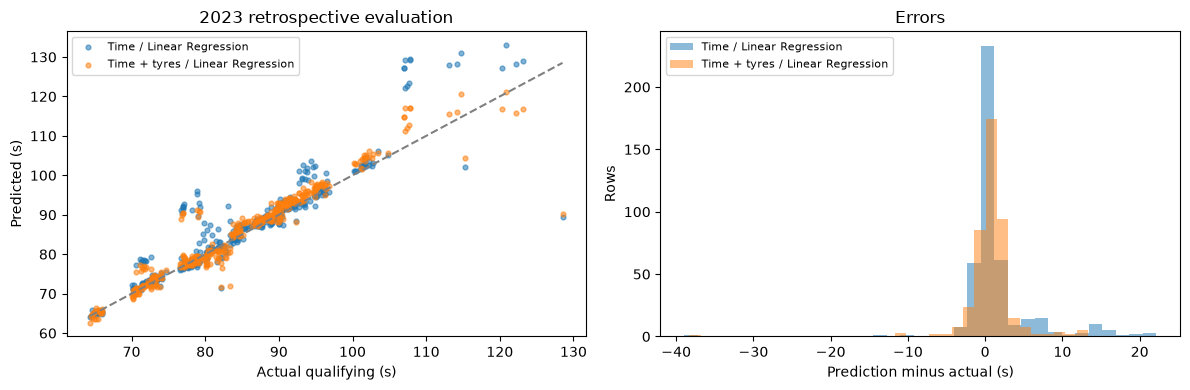

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for feature_set, winner in winners.items():
    label = f"{feature_set} / {winner}"
    axes[0].scatter(testing.QualiTime, predictions[label], s=12, alpha=.55, label=label)
    axes[1].hist(predictions[label] - testing.QualiTime, bins=35, alpha=.5, label=label)
limits = [testing.QualiTime.min(), testing.QualiTime.max()]
axes[0].plot(limits, limits, "--", color="gray")
axes[0].set(xlabel="Actual qualifying (s)", ylabel="Predicted (s)", title="2023 retrospective evaluation")
axes[1].set(xlabel="Prediction minus actual (s)", ylabel="Rows", title="Errors")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

อ่านกราฟ: จุดใกล้เส้นทแยงคือทำนายใกล้จริง จุดใต้เส้นคือทำนายเร็วเกินไป Histogram ใกล้ศูนย์คือ error น้อย
อย่าอ่านแค่ค่าเฉลี่ย เพราะความผิดพลาดบางสนามอาจสูงมาก
กลุ่ม wet ด้านล่างหมายถึงมี lap ที่ถูกเลือกอย่างน้อยหนึ่ง Practice ใช้ INTERMEDIATE/WET ไม่ได้ยืนยันว่าวัน Qualifying ฝนตก

In [25]:
evaluation_rows = testing.copy()
evaluation_rows["session_group"] = np.where(testing[TIMES].notna().all(axis=1), "complete", "missing")
wet = testing[COMPOUNDS].isin(["INTERMEDIATE", "WET"]).any(axis=1)
unknown = ((~testing[COMPOUNDS].isin(KINDS[:-1])).to_numpy() & testing[TIMES].notna().to_numpy()).any(axis=1)
evaluation_rows["tyre_group"] = np.where(wet, "wet", np.where(unknown, "unknown", "dry"))
group_scores = []
for name, values in predictions.items():
    evaluation_rows["prediction"] = values
    for column in ["event_id", "session_group", "tyre_group"]:
        for group, rows in evaluation_rows.groupby(column):
            group_scores.append({"model": name, "dimension": column, "group": group,
                                 **metrics(rows.QualiTime, rows.prediction)})
group_scores = pd.DataFrame(group_scores)
display(group_scores.loc[group_scores.model.eq(selected_name)])
group_scores.to_csv(PROCESSED / "group_scores_2023.csv", index=False)

time_winner = f"Time / {winners['Time']}"
lookup = scores.set_index("model")
for comparator in [time_winner, "Practice baseline"]:
    change = lookup.loc[selected_name, "rmse"] - lookup.loc[comparator, "rmse"]
    print(f"{selected_name} RMSE {'สูงกว่า (แย่กว่า)' if change > 0 else 'ต่ำกว่า (ดีกว่า)'} {comparator}: {abs(change):.3f} s")
print("ผลนี้เป็นการเปรียบเทียบย้อนหลัง ไม่ใช่หลักฐานเชิงสาเหตุหรือการรับประกันฤดูกาลถัดไป")

,model,dimension,group,count,mae,rmse
81,Time + tyres / Linear Regression,event_id,2023-01,20,2.472217,2.528803
82,Time + tyres / Linear Regression,event_id,2023-02,20,2.542796,8.588558
83,Time + tyres / Linear Regression,event_id,2023-03,19,0.467189,0.550568
84,Time + tyres / Linear Regression,event_id,2023-04,20,2.824480,3.506654
85,Time + tyres / Linear Regression,event_id,2023-05,20,0.940148,0.997522
86,Time + tyres / Linear Regression,event_id,2023-06,20,0.657685,0.886338
87,Time + tyres / Linear Regression,event_id,2023-07,20,0.850064,0.965729
88,Time + tyres / Linear Regression,event_id,2023-08,20,1.730453,2.071569
89,Time + tyres / Linear Regression,event_id,2023-09,20,0.659376,0.868722
90,Time + tyres / Linear Regression,event_id,2023-10,20,1.128440,1.589132


Time + tyres / Linear Regression RMSE ต่ำกว่า (ดีกว่า) Time / Linear Regression: 1.556 s
Time + tyres / Linear Regression RMSE ต่ำกว่า (ดีกว่า) Practice baseline: 1.073 s
ผลนี้เป็นการเปรียบเทียบย้อนหลัง ไม่ใช่หลักฐานเชิงสาเหตุหรือการรับประกันฤดูกาลถัดไป


## 5. ทดลองใช้และบันทึกโมเดล
### 5.1 กรอกข้อมูลเอง
ใช้เวลาหน่วยวินาที อายุยางคือจำนวนรอบที่ยางถูกใช้ ไม่ใช่อายุเป็นวัน
หากไม่มี session ให้ใช้ NaN ทั้ง triple; ถ้าไม่มี Practice เลยฟังก์ชันจะปฏิเสธ
ตัวอย่างนี้ไม่มีชื่อนักขับ ทีม สนาม หรือปีในการทำนาย

In [26]:
new_input = pd.DataFrame([{
    "FP1_Time": 93.0, "FP1_Compound": "SOFT", "FP1_TyreLife": 3,
    "FP2_Time": 91.0, "FP2_Compound": "SOFT", "FP2_TyreLife": 4,
    "FP3_Time": np.nan, "FP3_Compound": None, "FP3_TyreLife": np.nan,
}])
filled_input = fill_sessions(new_input)
display(filled_input)
prediction = float(active["models"][active["winner"]].predict(transform(new_input, active["processor"]))[0])
print(f"Qualifying ที่ทำนาย: {prediction:.3f} s")
print(f"ช่วงอ้างอิงย้อนหลัง: {prediction + lo:.3f} ถึง {prediction + hi:.3f} s")
print("เป็น scenario ของโมเดล ไม่ใช่ผลเชิงสาเหตุ")
for column in TIMES + AGES:
    value = filled_input.iloc[0][column]
    train_values = fill_sessions(final_fit)[column]
    if pd.notna(value) and not train_values.min() <= value <= train_values.max():
        print(column, "อยู่นอกช่วงฝึก")

,FP1_Time,FP1_Compound,FP1_TyreLife,FP2_Time,FP2_Compound,FP2_TyreLife,FP3_Time,FP3_Compound,FP3_TyreLife,FP1_filled_from,FP2_filled_from,FP3_filled_from
0,93.0,SOFT,3.0,91.0,SOFT,4.0,91.0,SOFT,4.0,FP1,FP2,FP2


Qualifying ที่ทำนาย: 91.332 s
ช่วงอ้างอิงย้อนหลัง: 71.255 ถึง 98.512 s
เป็น scenario ของโมเดล ไม่ใช่ผลเชิงสาเหตุ


### 5.2 Save / load ให้ผลเหมือนเดิม
เก็บ preprocessing กับ estimator คู่กัน ห้ามโหลด estimator แล้วป้อนข้อมูลดิบ 9 คอลัมน์โดยข้าม encoding/scaling
ไฟล์ของ Notebook แยกจากเว็บ เพื่อไม่เขียนทับโมเดลที่กำลังให้บริการ

In [27]:
model_path = PROCESSED / "notebook_model.joblib"
joblib.dump({"experiment": active, "residual_lower": lo, "residual_upper": hi}, model_path)
loaded = joblib.load(model_path)
loaded_model = loaded["experiment"]
loaded_prediction = loaded_model["models"][loaded_model["winner"]].predict(transform(new_input, loaded_model["processor"]))[0]
np.testing.assert_allclose(prediction, loaded_prediction, atol=1e-9)
print("saved:", model_path.resolve())
print("prediction ก่อน/หลังโหลด:", prediction, loaded_prediction)

saved: /workspace/f1_project/artifacts/practice-tyres-notebook/notebook_model.joblib
prediction ก่อน/หลังโหลด: 91.3319686254539 91.3319686254539


### 5.3 ตรวจเทียบ Notebook กับโค้ดเว็บ
ขั้นหลักทำใน Notebook ครบแล้ว ขั้นนี้เท่านั้นที่ import implementation ของเว็บมา **ตรวจคำตอบ** ไม่ใช่ใช้ทำงานแทน cells ก่อนหน้า
ตรวจตาราง features, ค่าทำนายทุก configuration, custom input และ checksum raw

In [28]:
from intelligence.data import Dataset
from intelligence import tyre_model as web_model

web_data = Dataset()
web_features = web_model.build_features(web_data)
compare_columns = ["event_id", "Driver", *FEATURES["Time + tyres"],
                   *[f"{s}_source_row" for s in SESSIONS], "QualiTime"]
pd.testing.assert_frame_equal(features[compare_columns].reset_index(drop=True),
                              web_features[compare_columns].reset_index(drop=True), check_dtype=False)
web_bundle = web_model.ensure_artifacts(web_data)
for feature_set, experiment in experiments.items():
    other = web_bundle["experiments"][feature_set]
    assert experiment["winner"] == other["winner"]
    for name, model in experiment["models"].items():
        np.testing.assert_allclose(model.predict(transform(testing, experiment["processor"])),
                                   other["models"][name].predict(web_model.transform(testing, other["processor"])), atol=1e-8)
request = {"FP1": {"time": 93, "compound": "SOFT", "tyre_life": 3},
           "FP2": {"time": 91, "compound": "SOFT", "tyre_life": 4}}
api_logic = web_model.custom_predict(web_bundle, request)
np.testing.assert_allclose(prediction, api_logic["prediction"], atol=1e-8)
from fastapi.testclient import TestClient
from intelligence.api import app
with TestClient(app) as client:
    response = client.post("/api/v1/predict/custom", json=request)
    assert response.status_code == 200, response.text
    np.testing.assert_allclose(prediction, response.json()["prediction"], atol=1e-8)
assert checksums(RAW) == raw_before
print("PASS: features / 4 models / saved model / web prediction logic / raw unchanged")
display(pd.DataFrame({"check": ["raw checksum unchanged", "notebook/web parity"], "passed": [True, True]}))

/usr/local/lib/python3.11/site-packages/fastapi/testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


PASS: features / 4 models / saved model / web prediction logic / raw unchanged


,check,passed
0,raw checksum unchanged,True
1,notebook/web parity,True


## สรุปสิ่งที่ทำและข้อจำกัด
เราเห็น raw ก่อน clean, เหตุผลที่ตัดแถว, lap ต้นทางของ features, วิธีเติม missing, train-only preprocessing และผลเปรียบเทียบแล้ว

- Model ที่เว็บใช้มาจากชุดเวลา+ยาง และเลือกอัลกอริทึมด้วย validation ไม่เลือกตามปี 2023
- SOFT/MEDIUM/HARD เป็นชื่อสัมพัทธ์ของยางในแต่ละ weekend ไม่ใช่รับรองว่าส่วนผสมเดียวกันทุกสนาม
- ไม่ได้รู้เชื้อเพลิง setup การจราจร หรือแผนวิ่ง จึงอธิบายเวลาไม่ได้ทั้งหมด
- การใช้ lap เร็วที่สุดสรุปข้อมูลได้หนึ่งแถวต่อคน/สนาม แต่ทิ้งรายละเอียด long run นี่เป็นขอบเขตของการทดลองนี้
- 2023 เป็นการประเมินย้อนหลังที่เคยเห็นข้อมูลแล้ว หากต้องการประเมินใหม่อย่างเข้มงวดควรกำหนดฤดูกาลใหม่ไว้ล่วงหน้า
- ข้อมูลและ API: [FastF1](https://github.com/theOehrly/Fast-F1) · [data reference](https://docs.fastf1.dev/data_reference/index.html)